
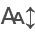

In [1]:
from itables import init_notebook_mode  
from IPython.display import display
init_notebook_mode(all_interactive=True)

In [2]:
import pandas as pd

In [3]:
base_path = "PhysicalAI-Robotics-Manipulation-SingleArm/panda-stack-platforms-texture/data"
file_path = "chunk-000/episode_000000.parquet"

df = pd.read_parquet(base_path + "\\" + file_path)

In [4]:
df

action  \
0   [0.058240462, 0.107649654, -0.10220728, -0.067...   
1   [0.058238395, 0.107645504, -0.102203645, -0.06...   
2   [0.058238607, 0.10764543, -0.10220361, -0.0674...   
3   [0.058238566, 0.1076457, -0.10220358, -0.06742...   
4   [0.058238503, 0.107645795, -0.10220346, -0.067...   
..                                                ...   
86  [-0.022100473, 0.14551388, 0.09128727, 0.05094...   
87  [5.256393e-05, 0.00023364811, -9.422603e-05, -...   
88  [4.0114655e-06, -9.604629e-06, -1.4733898e-05,...   
89  [0.031583745, -0.20729637, -0.1304049, -0.0727...   
90  [0.031717125, -0.20772311, -0.130678, -0.07294...   

                                    observation.state  timestamp  frame_index  \
0   [0.22115414, 0.047975525, -0.0050000045, -0.42...   0.000000            0   
1   [0.22115414, 0.047975525, -0.0050000045, -0.40...   0.033333            1   
2   [0.22115414, 0.047975525, -0.0050000045, -0.37...   0.066667            2   
3   [0.22115414, 0.047975525, -0.0050000045, -0.35...   0.100000            3   
4   [0.22115414, 0.047975525, -0.0050000045, -0.32...   0.133333            4   
..                                                ...        ...          ...   
86  [0.53782237, -0.28317404, 0.06354245, 0.014029...   2.866667           86   
87  [0.5406057, -0.27914524, 0.051328786, 0.014031...   2.900000           87   
88  [0.5390812, -0.27792323, 0.051262133, 0.014083...   2.933333           88   
89  [0.53982204, -0.27868342, 0.049440548, 0.01510...   2.966667           89   
90  [0.53989536, -0.2786638, 0.049444858, 0.018725...   3.000000           90   

    episode_index  index  task_index  
0               0      0           0  
1               0      1           0  
2               0      2           0  
3               0      3           0  
4               0      4           0  
..            ...    ...         ...  
86              0     86           0  
87              0     87           0  
88              0     88           0  
89              0     89           0  
90              0     90           0  

[91 rows x 7 columns]

In [17]:
df.to_csv("episode_000000.csv")

In [5]:
base_path = "PhysicalAI-Robotics-Manipulation-SingleArm/panda-stack-platforms-texture"
file_path = "meta/episodes_stats.jsonl"

# df = pd.read_parquet(base_path + "\\" + file_path, lines=True)
df = pd.read_json(base_path + "\\" + file_path, lines=True)

In [6]:
df['stats'].iloc[0]

{'action': {'min': [-0.12128557264804801,
   -0.20772311091423,
   -0.13067799806594801,
   -0.07294737547636,
   -0.259496122598648,
   -0.164742067456245,
   -0.18085859715938502,
   -1.0],
  'max': [0.169223874807357,
   0.20766389369964602,
   0.130365535616874,
   0.20781971514225,
   0.24951609969139102,
   0.07827404141426,
   0.188611537218093,
   1.0],
  'mean': [-0.002400706056505,
   0.07241374999284701,
   -0.039054412394762004,
   0.052459262311458005,
   0.06692303717136301,
   -0.05590749531984301,
   0.061190720647573006,
   -0.5274725556373591],
  'std': [0.052218042314052006,
   0.116634309291839,
   0.065052680671215,
   0.11525921523571,
   0.172698706388473,
   0.061717592179775,
   0.113542310893535,
   0.580652296543121],
  'count': [91]},
 'observation.depths.hand_camera': {'min': [[[0.011764705882352]],
   [[0.011764705882352]],
   [[0.011764705882352]]],
  'max': [[[0.258823529411764]], [[0.258823529411764]], [[0.258823529411764]]],
  'mean': [[[0.034323546245

In [7]:
df['stats'].iloc[0].keys()

dict_keys(['action', 'observation.depths.hand_camera', 'observation.images.hand_camera', 'observation.depths.world_camera', 'observation.images.world_camera', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'])

# collect data

In [22]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

base_path = "PhysicalAI-Robotics-Manipulation-SingleArm/panda-stack-platforms-texture/data"

# Loop through all episodes
episode_data = []

for chunk_folder in os.listdir(base_path):
    chunk_path = os.path.join(base_path, chunk_folder)
    if not os.path.isdir(chunk_path):
        continue

    for file_name in tqdm(os.listdir(chunk_path)):
        if not file_name.endswith(".parquet"):
            continue

        file_path = os.path.join(chunk_path, file_name)
        try:
            df = pd.read_parquet(file_path)

            # Target: duration in seconds
            num_steps = len(df)
            duration = num_steps / 30.0

            # Features: observations.state from first timestep
            first_row = df.iloc[0]
            state = first_row["observation.state"]
            feature_dict = {f"state_{i}": val for i, val in enumerate(state)}
            action = first_row["action"]
            feature_dict = feature_dict | {f"action_{i}": val for i, val in enumerate(action)}

            # Combine into one row
            feature_dict["duration_seconds"] = duration
            feature_dict["file"] = file_name

            episode_data.append(feature_dict)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Create final dataset
df_all = pd.DataFrame(episode_data)
print("Final dataset shape:", df_all.shape)


100%|███████████████████████████████████████████████████████████████████████████████| 303/303 [00:00<00:00, 592.95it/s]


Final dataset shape: (6303, 91)


In [24]:
df_all

state_0   state_1  state_2   state_3   state_4   state_5       state_6  \
0     0.221154  0.047976   -0.005 -0.422386 -0.031988  0.218783 -2.712781e-09   
1     0.511915  0.197079   -0.005 -0.223624 -0.194491  0.413315  1.957095e-08   
2     0.486492  0.273943   -0.005 -0.262085 -0.281387  0.402854  4.555545e-09   
3     0.536662  0.004033   -0.005 -0.213509 -0.007809  0.426311 -5.157559e-09   
4     0.391906 -0.045836   -0.005 -0.304658  0.045151  0.332304  3.497705e-09   
...        ...       ...      ...       ...       ...       ...           ...   
6298  0.297664  0.349022   -0.005 -0.343809 -0.365569  0.273051 -4.504155e-09   
6299  0.351146 -0.186038   -0.005 -0.348548  0.167850  0.301245 -7.686191e-09   
6300  0.273771  0.193174   -0.005 -0.375325 -0.200308  0.255531  1.135258e-08   
6301  0.366705 -0.254147   -0.005 -0.322505  0.248225  0.314086  6.087454e-10   
6302  0.270549 -0.165908   -0.005 -0.425554  0.130541  0.240805 -1.138557e-08   

           state_7   state_8   state_9  ...  action_0  action_1  action_2  \
0     8.832444e-09  0.750202  0.661209  ...  0.058240  0.107650 -0.102207   
1    -3.760359e-09 -0.008250  0.999966  ...  0.010395  0.207926  0.042022   
2    -1.008923e-08 -0.687191  0.726477  ...  0.067011  0.170510  0.022635   
3    -1.807641e-08  0.221624  0.975132  ...  0.044849  0.207923 -0.041019   
4    -7.013401e-09 -0.541529  0.840682  ...  0.037855  0.206008 -0.116788   
...            ...       ...       ...  ...       ...       ...       ...   
6298  7.343022e-09 -0.472017  0.881589  ...  0.207891  0.142968 -0.049895   
6299 -1.448575e-08 -0.420827  0.907141  ... -0.207909  0.127193  0.106230   
6300 -9.251755e-10 -0.563516  0.826105  ...  0.108946  0.208040  0.185321   
6301  1.288013e-08 -0.689457  0.724327  ... -0.142665  0.207920 -0.029018   
6302 -5.213908e-09 -0.990261  0.139227  ... -0.004016 -0.076467 -0.207920   

      action_3  action_4  action_5  action_6  action_7  duration_seconds  \
0    -0.067426  0.249516 -0.133728  0.112927       0.0          3.033333   
1     0.187124  0.000274 -0.194065  0.061165       0.0          2.933333   
2     0.207913 -0.091470 -0.227250 -0.093637       0.0          2.766667   
3     0.144020  0.004061 -0.135144 -0.076212       0.0          1.966667   
4     0.119499  0.140993 -0.249518  0.012354       0.0          2.900000   
...        ...       ...       ...       ...       ...               ...   
6298  0.049790  0.029357 -0.052497 -0.246195       0.0          2.500000   
6299  0.014852 -0.031594 -0.042388  0.103583       0.0          2.833333   
6300  0.069690 -0.135117 -0.223962 -0.072800       0.0          2.233333   
6301  0.097612  0.089879 -0.142991  0.154911       0.0          2.433333   
6302 -0.003908 -0.051488 -0.033266 -0.158898       0.0          4.000000   

                        file  
0     episode_000000.parquet  
1     episode_000001.parquet  
2     episode_000002.parquet  
3     episode_000003.parquet  
4     episode_000004.parquet  
...                      ...  
6298  episode_006298.parquet  
6299  episode_006299.parquet  
6300  episode_006300.parquet  
6301  episode_006301.parquet  
6302  episode_006302.parquet  

[6303 rows x 91 columns]

# EDA

<Axes: xlabel='duration_seconds', ylabel='Count'>

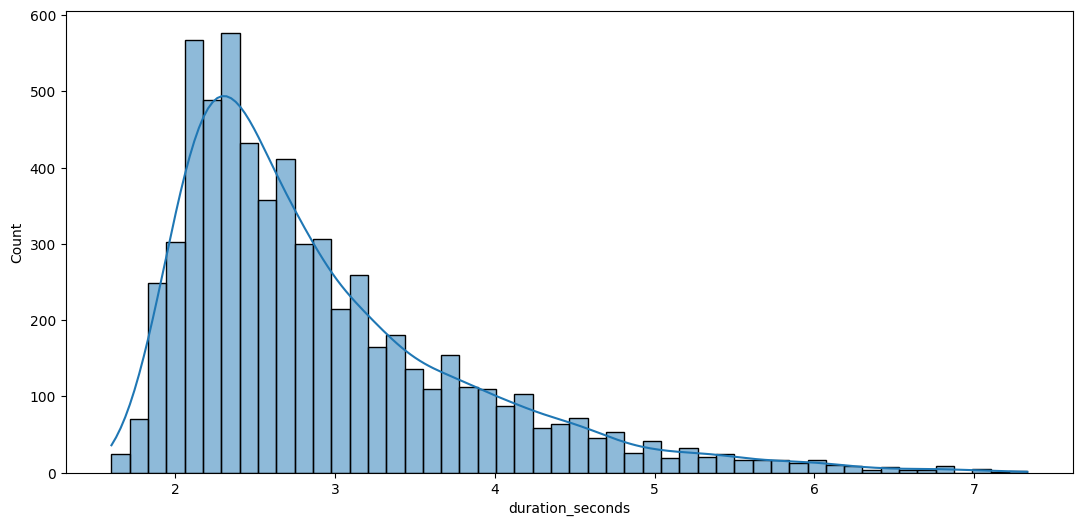

In [25]:
plt.figure(figsize=(13,6))
sns.histplot(
    data=df_all, 
    x="duration_seconds", 
    kde=True
)

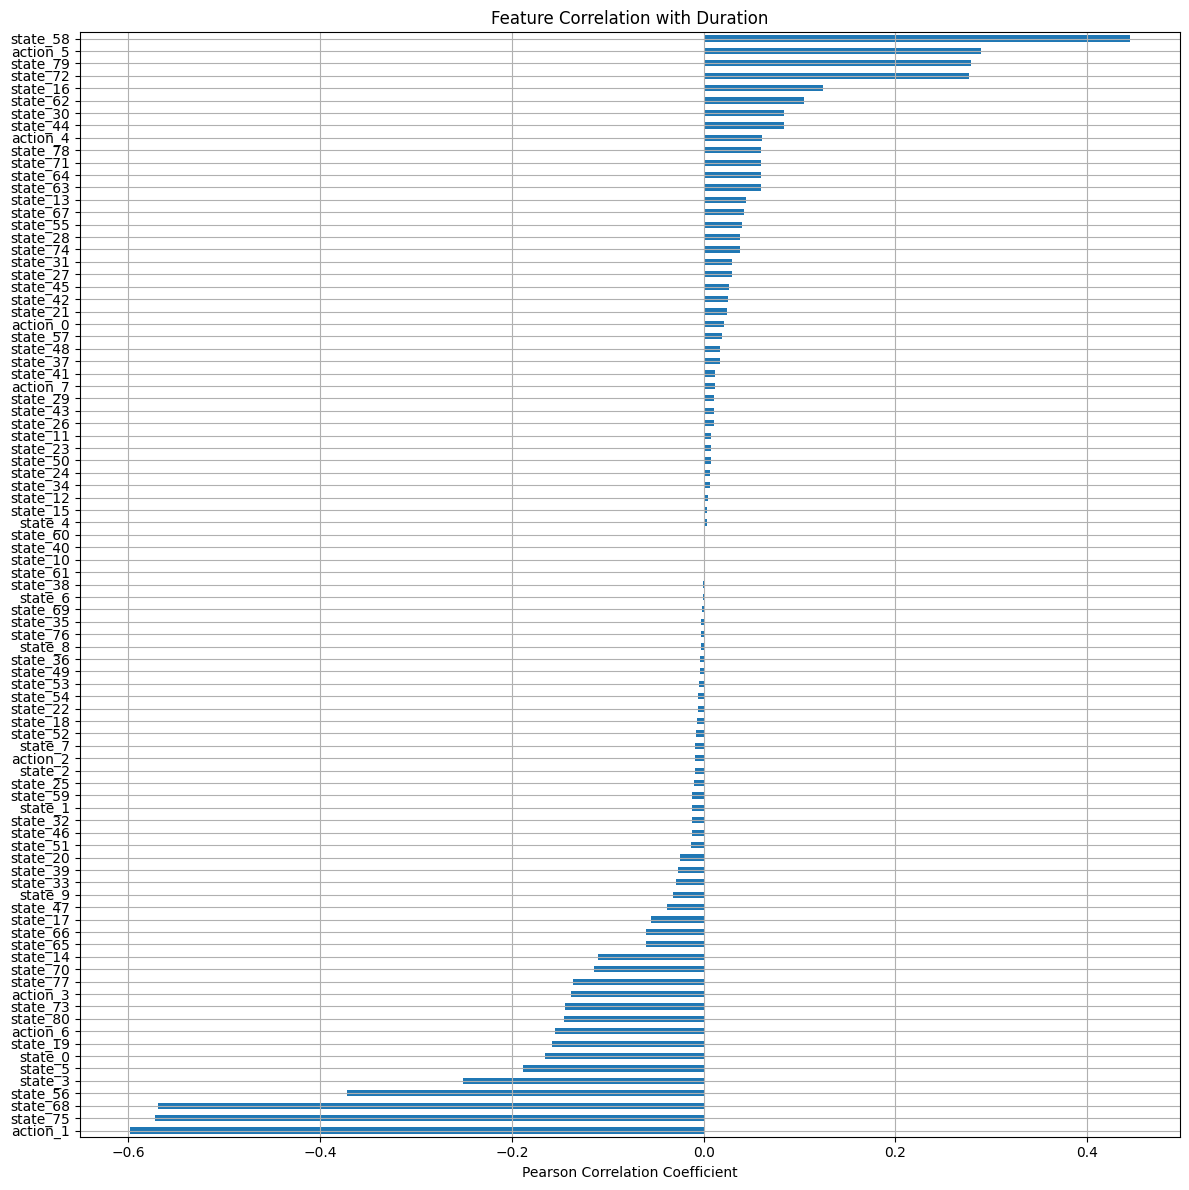

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation between features and target
correlations = df_all.drop(columns=["file"]).corr()["duration_seconds"].drop("duration_seconds")

# Plot correlation
plt.figure(figsize=(12, 12))
correlations.sort_values().plot(kind="barh", title="Feature Correlation with Duration")
plt.xlabel("Pearson Correlation Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()


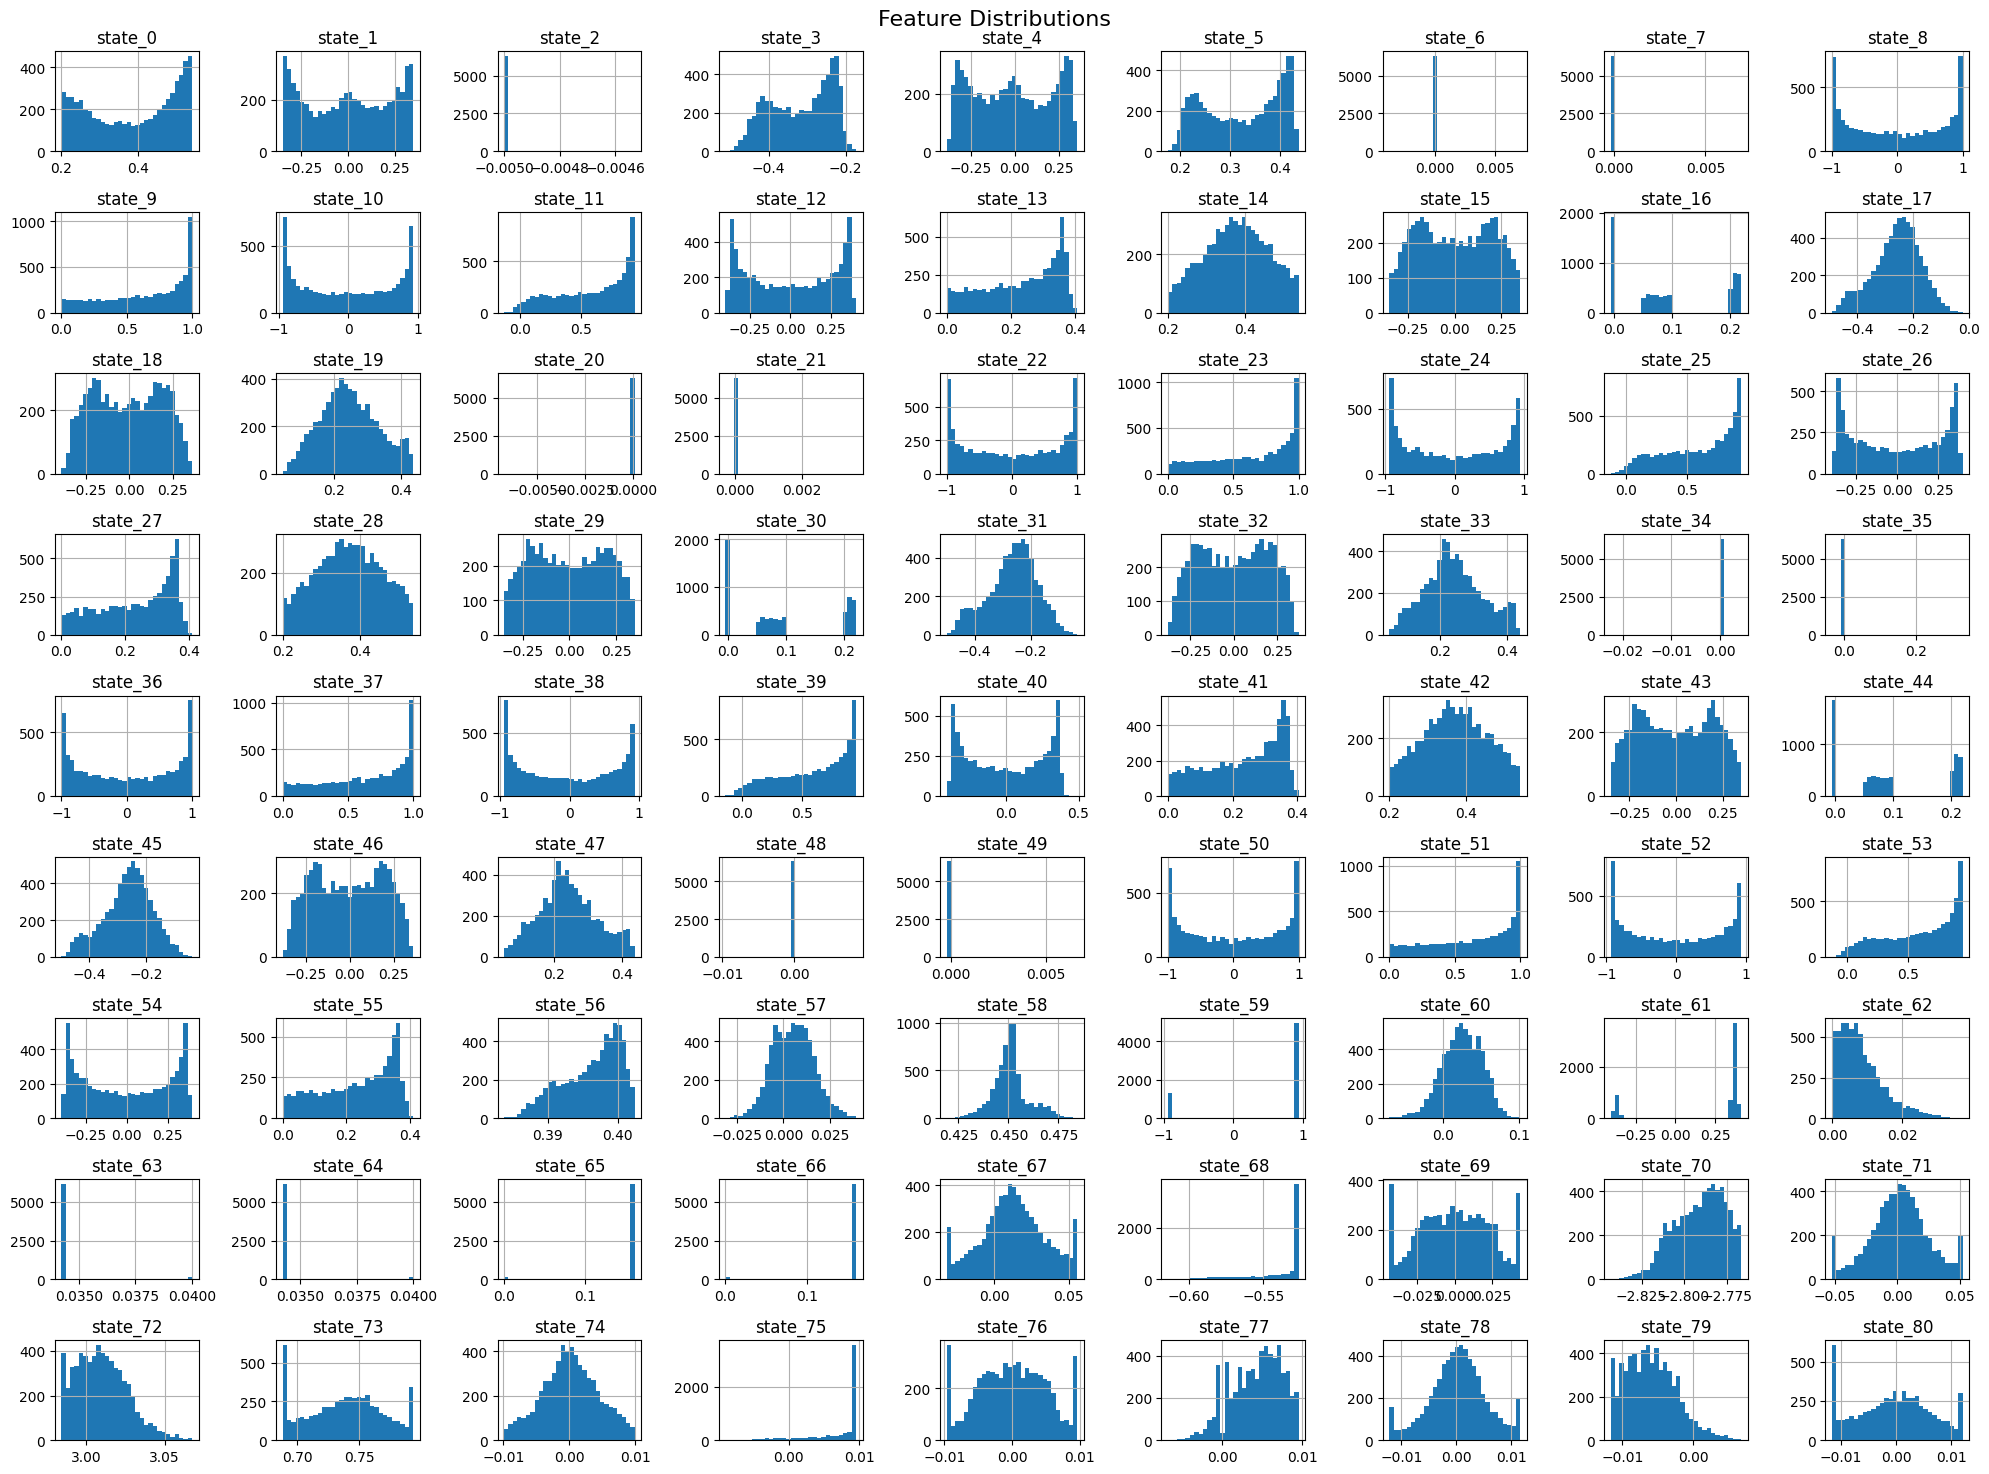

In [27]:
# Plot histograms for all state features
feature_cols = [col for col in df_all.columns if col.startswith("state_")]

df_all[feature_cols].hist(figsize=(20, 15), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'action_1'}>,
        <Axes: title={'center': 'state_75'}>],
       [<Axes: title={'center': 'state_68'}>,
        <Axes: title={'center': 'state_58'}>],
       [<Axes: title={'center': 'state_56'}>, <Axes: >]], dtype=object)

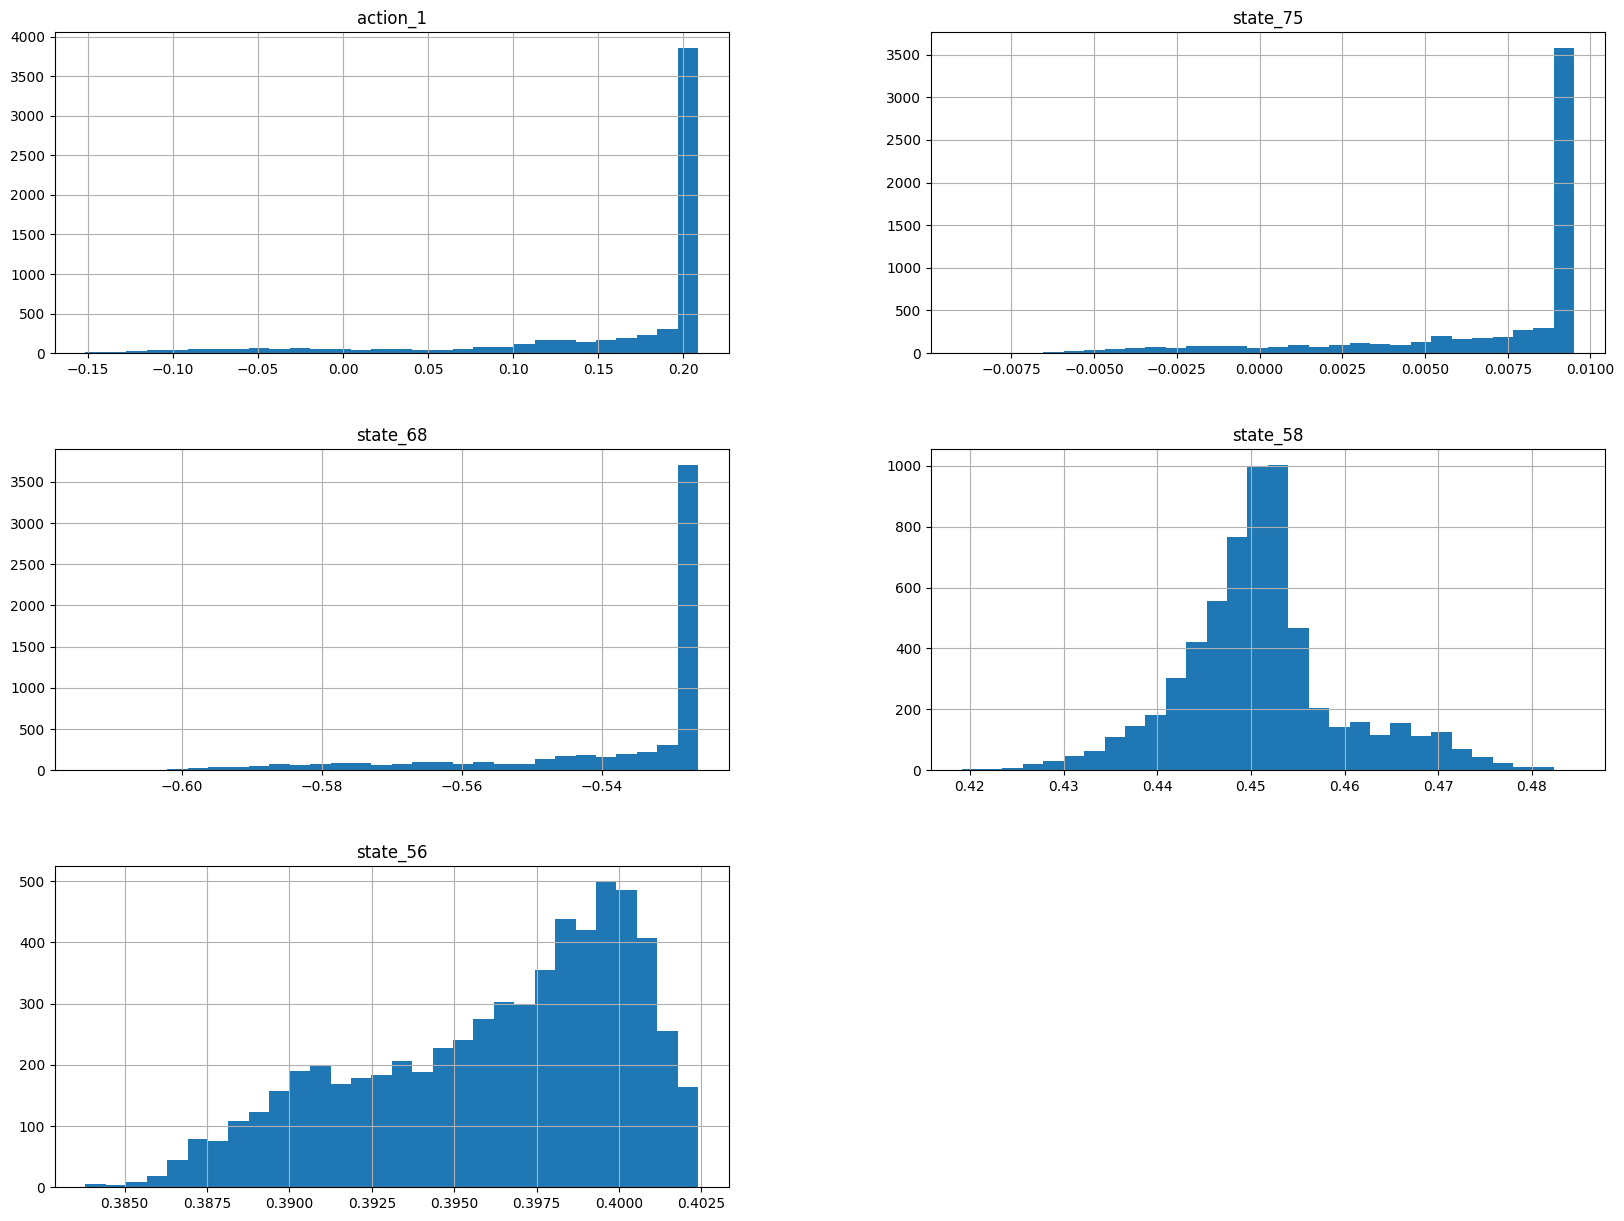

In [33]:
# Plot 5 most correlated features vs. duration
top_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()

df_all[top_features].hist(figsize=(20, 15), bins=30)

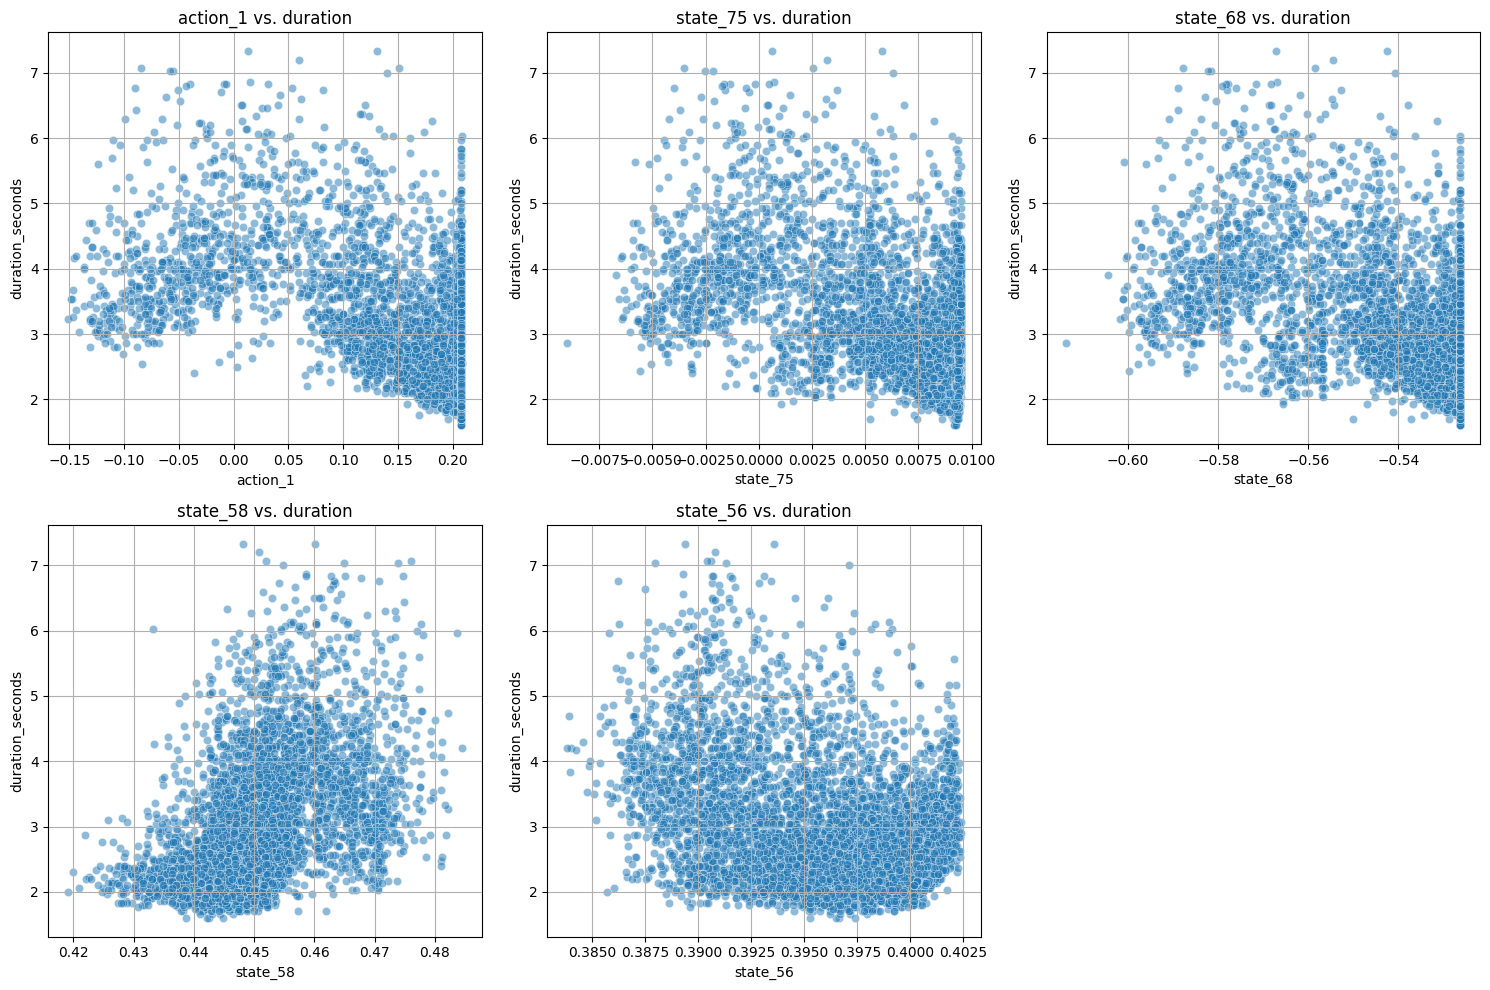

In [28]:
# Plot 5 most correlated features vs. duration
top_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()

plt.figure(figsize=(15, 10))
for i, feat in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(data=df_all, x=feat, y="duration_seconds", alpha=0.5)
    plt.title(f"{feat} vs. duration")
    plt.grid(True)
plt.tight_layout()
plt.show()


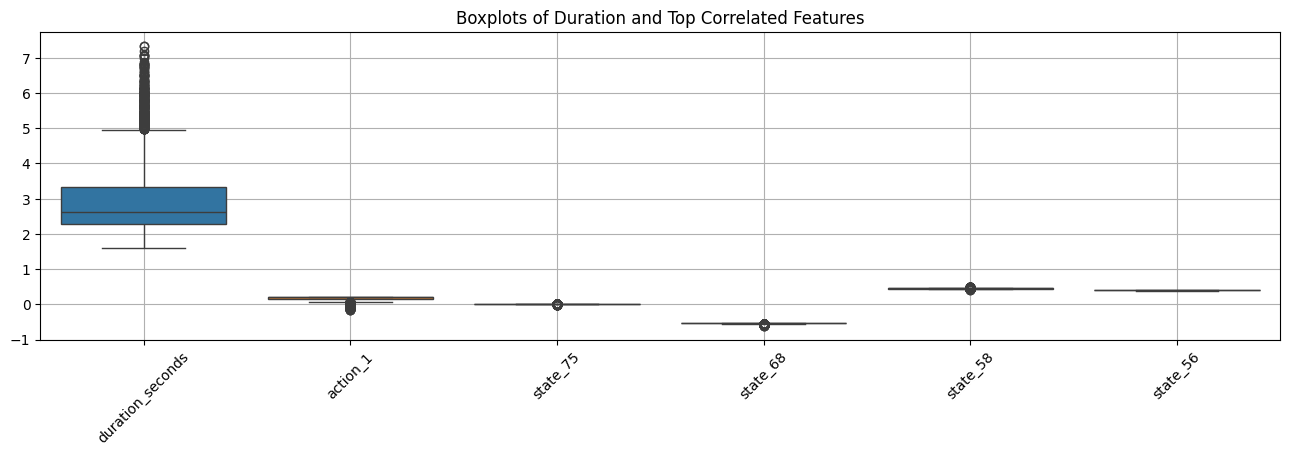

In [29]:
plt.figure(figsize=(16, 4))
sns.boxplot(data=df_all[["duration_seconds"] + top_features])
plt.xticks(rotation=45)
plt.title("Boxplots of Duration and Top Correlated Features")
plt.grid(True)
plt.show()


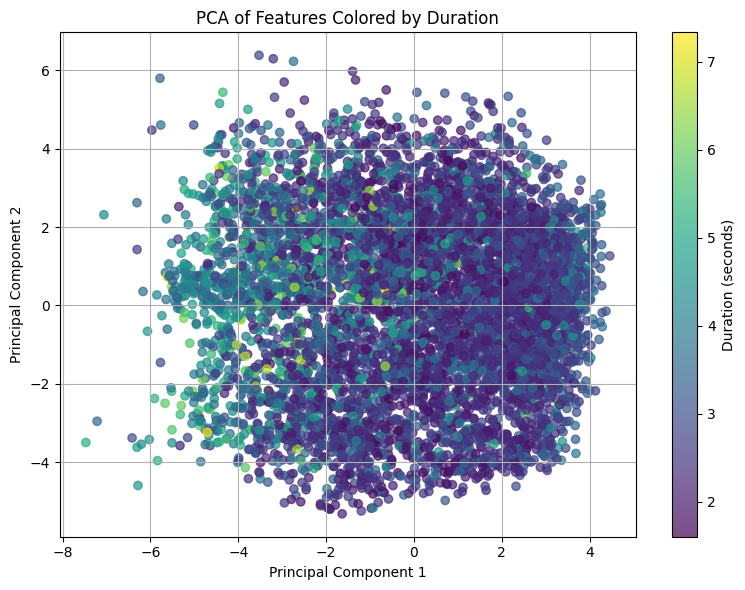

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Feature columns
feature_cols = [col for col in df_all.columns if col.startswith("state_")]

# Standardize features
X_scaled = StandardScaler().fit_transform(df_all[feature_cols])

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot with colorbar using matplotlib
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_all["duration_seconds"], cmap="viridis", alpha=0.7)
plt.title("PCA of Features Colored by Duration")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
cbar = plt.colorbar(scatter)
cbar.set_label("Duration (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()


# base model

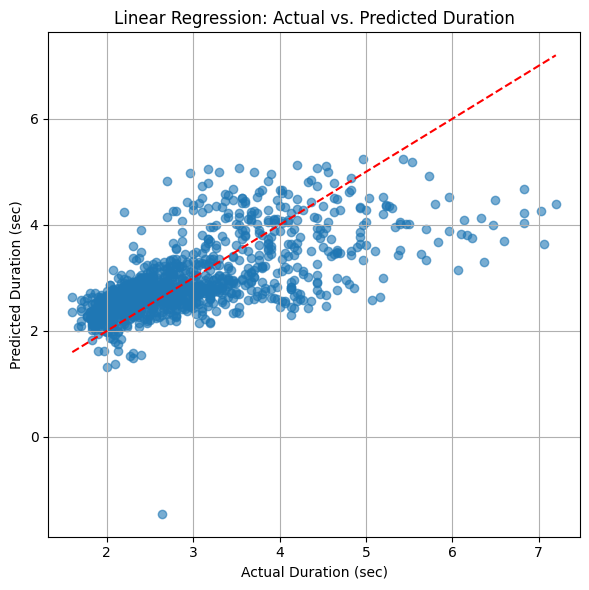

Mean Squared Error: 0.4779
R² Score: 0.4429


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Define features and target
X = df_all.drop(columns=["duration_seconds", "file"])
y = df_all["duration_seconds"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Plot actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Duration (sec)")
plt.ylabel("Predicted Duration (sec)")
plt.title("Linear Regression: Actual vs. Predicted Duration")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
